In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.optimize import minimize
from scipy.stats import kstest, expon
import time
from numba import njit
import pandas as pd
import pickle as pkl
import copy
import random
import importlib
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm, BoundaryNorm
from matplotlib.colors import ListedColormap
import seaborn as sns
from collections import defaultdict
np.set_printoptions(threshold=np.inf)

%cd ..
import ClassGVM
importlib.reload(ClassGVM)
from ClassGVM import logit, der_logit, negloglikelihood_with_grad_single_jit
from ClassGVM import ExponentialHawkesGVM

/Users/sachaquayle/Desktop/hawkes-vm/python/gvm model (article1)/GitHub


# Comparison KS/CvM

In [82]:
d = 10

mu = np.array([1.0, 1.3, 1.2, 0.8, 0.5, 0.3, 1.1, 1.0, 0.3, 1.5])

alpha = np.array( [ [0.5, 0.0, 0.2, -0.8, 0.5, 0.7, 0.0, 0.0, 0.0, 0.0],
                    [1.0, -0.5, -0.2, 0.0, 0.2, 0.0, 0.0, 0.0, 0.0, 0.0],
                    [0.2, -0.9, 0.7, 0.1, -0.1, 0.3, 0.0, 0.0, 0.0, 0.0],
                    [-0.4, 0.0, 1.2, -0.8, 0.2, 0.2, 0.0, 0.0, 0.0, 0.0],
                    [1.2, 0.3, 0.0, 0.0, 0.7, 0.0, 0.0, 0.0, 0.0, 0.0],
                    [0.0, -0.1, 1.0, -0.8, 0.1, 0.2, 0.0, 0.0, 0.0, 0.0],
                    [0.0, 0.0, 0.0, 0.0, 0.0, 0.5, -0.1, -0.2, -0.1, 0.0],
                    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.5, 0.0],
                    [0.0, 0.0, 0.0, 0.0, 0.0, 0.3, 0.3, 0.5, -0.1, 0.0],
                    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.4, 0.6] ])

beta = np.array([6.0, 3.0, 2.2, 3.6, 6.0, 1.4, 2.4, 2.0, 1.6, 2.4])

alpha_tilde = copy.deepcopy(alpha)

####### Simulate data #######

nb_realisations = 25
size = 5000

hawkes = ExponentialHawkesGVM(model='gvm', mu=mu, alpha=alpha, beta=beta, alpha_tilde=alpha_tilde)
times = hawkes.simulate(size=size, nb_realisations=nb_realisations)


In [83]:
hawkes = ExponentialHawkesGVM()
hawkes.d = d
hawkes.times = times
hawkes.nb_realisations = len(times)
hawkes.estimation = [mu, alpha, beta, alpha_tilde]

With CVM:


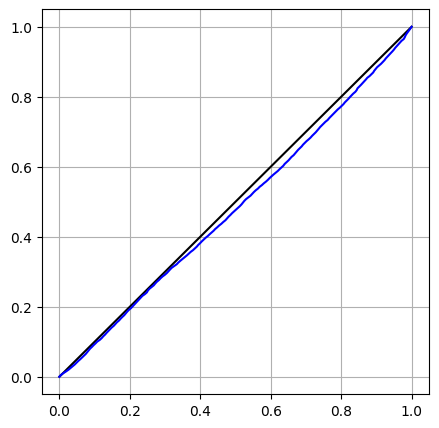

Average p-value: 0.49540652722637013


In [96]:
print('With CVM:')

nb_iterations = 10000 # for resampling

pvalues_cvm = hawkes.pvalues(nb_iterations=nb_iterations, distribution='expon', method='cramervonmises', av_estimation=False)

fig,ax=plt.subplots(figsize=(5,5))
nb = 200
y = np.linspace(0, 1, nb)

values = np.array([np.mean(pvalues_cvm <= yk) for yk in y])

ax.plot(y, y,color='black')
ax.plot(values, y,color='blue')
ax.grid()
plt.show()

print('Average p-value:', np.mean(pvalues_cvm))

In [86]:
rejection_values = np.array([0.01,0.025,0.05,0.1, 0.2])
rejection_rates = np.array([np.mean(pvalues_cvm<x) for x in rejection_values])
print(rejection_rates)

[0.0103 0.0294 0.0539 0.1057 0.2064]


With KS:


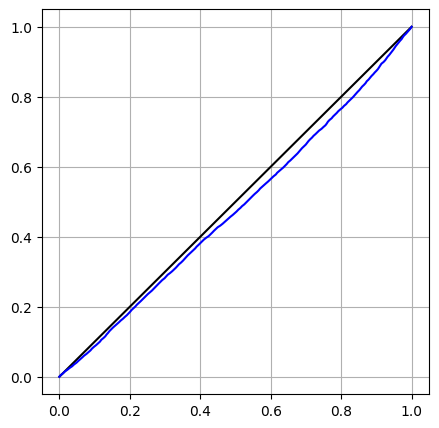

Average p-value: 0.47739507246878793


In [98]:
print('With KS:')

nb_iterations = 10000 # for resampling

pvalues = hawkes.pvalues(nb_iterations=nb_iterations, distribution='expon', method='kstest', av_estimation=False)

fig,ax=plt.subplots(figsize=(5,5))
nb = 200
y = np.linspace(0, 1, nb)

values = np.array([np.sum(pvalues <= yk) / nb_iterations for yk in y])

ax.plot(y, y,color='black')
ax.plot(values, y,color='blue')
ax.grid()
plt.show()

print('Average p-value:', np.mean(pvalues))

In [105]:
rejection_values = np.array([0.01,0.025,0.05,0.1, 0.2])
rejection_rates = np.array([np.mean(pvalues<x) for x in rejection_values])
print(rejection_rates)

[0.0156 0.034  0.0642 0.1198 0.2198]


# Comparison empirical/student confidence intervals

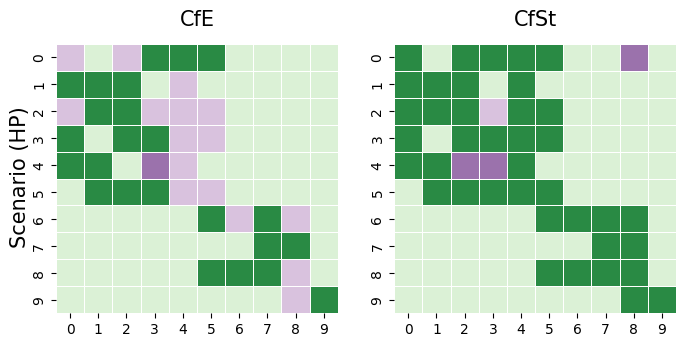

In [3]:
### Under Model (HP) ###

d = 10

mu = np.array([1.0, 1.3, 1.2, 0.8, 0.5, 0.3, 1.1, 1.0, 0.3, 1.5])

alpha = np.array( [ [0.5, 0.0, 0.2, -0.8, 0.5, 0.7, 0.0, 0.0, 0.0, 0.0],
                    [1.0, -0.5, -0.2, 0.0, 0.2, 0.0, 0.0, 0.0, 0.0, 0.0],
                    [0.2, -0.9, 0.7, 0.1, -0.1, 0.3, 0.0, 0.0, 0.0, 0.0],
                    [-0.4, 0.0, 1.2, -0.8, 0.2, 0.2, 0.0, 0.0, 0.0, 0.0],
                    [1.2, 0.3, 0.0, 0.0, 0.7, 0.0, 0.0, 0.0, 0.0, 0.0],
                    [0.0, -0.1, 1.0, -0.8, 0.1, 0.2, 0.0, 0.0, 0.0, 0.0],
                    [0.0, 0.0, 0.0, 0.0, 0.0, 0.5, -0.1, -0.2, -0.1, 0.0],
                    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.5, 0.0],
                    [0.0, 0.0, 0.0, 0.0, 0.0, 0.3, 0.3, 0.5, -0.1, 0.0],
                    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.4, 0.6] ])

beta = np.array([6.0, 3.0, 2.2, 3.6, 6.0, 1.4, 2.4, 2.0, 1.6, 2.4])

alpha_tilde = copy.deepcopy(alpha)

####### Simulate data #######

nb_realisations = 25
size = 5000

hawkes_sim = ExponentialHawkesGVM(model='gvm', mu=mu, alpha=alpha, beta=beta, alpha_tilde=alpha_tilde)
times = hawkes_sim.simulate(size=size, nb_realisations=nb_realisations)

####### Estimate #######

hawkes = ExponentialHawkesGVM()
hawkes.fit(times)

hawkes.test_absence_interactions(asymptotic=False)
interaction_matrix_cfe = copy.deepcopy(hawkes.alpha_zero_coefficients)

hawkes.test_absence_interactions(asymptotic=True)
interaction_matrix_cfst = copy.deepcopy(hawkes.alpha_zero_coefficients)

fig, axes = plt.subplots(1,2,figsize=(8, 3.5))

colors = ["#ff8a8e", "white", "#00ff2c"]
custom_cmap_real = LinearSegmentedColormap.from_list("custom_cmap", colors)
custom_cmap = ListedColormap(["#dbf1d6","#9b72ac", "#d9c2de", "#298a44"]) 

# Cfe

categorical_matrix = np.ones((d, d))
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_matrix_cfe, 0, categorical_matrix)  # Correct zero
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_matrix_cfe, 1, categorical_matrix)  # Undetected zero
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_matrix_cfe, 2, categorical_matrix)  # False zero detected
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_matrix_cfe, 3, categorical_matrix)  # Correct non-zero

sns.heatmap(
    categorical_matrix,
    ax=axes[0],
    cmap=custom_cmap,
    annot=False,
    cbar=False,  
    vmin=0,
    vmax=4,
    linewidths=0.5,
    linecolor='white'
)

axes[0].tick_params(axis='x')
axes[0].tick_params(axis='y')

# Cfst

categorical_matrix = np.ones((d, d))
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_matrix_cfst, 0, categorical_matrix)  # Correct zero
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_matrix_cfst, 1, categorical_matrix)  # Undetected zero
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_matrix_cfst, 2, categorical_matrix)  # False zero detected
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_matrix_cfst, 3, categorical_matrix)  # Correct non-zero

sns.heatmap(
    categorical_matrix,
    ax=axes[1],
    cmap=custom_cmap,
    annot=False,
    cbar=False,  
    vmin=0,
    vmax=4,
    linewidths=0.5,
    linecolor='white'
)

axes[1].tick_params(axis='x')
axes[1].tick_params(axis='y')



titlesize = 15
pad = 13
axes[0].set_title(r"CfE", fontsize=titlesize, pad=pad)
axes[1].set_title(r"CfSt", fontsize=titlesize, pad=pad)
fig.text(0.08, 0.5,'Scenario (HP)', va='center', ha='center', rotation='vertical', fontsize=15)

plt.show()


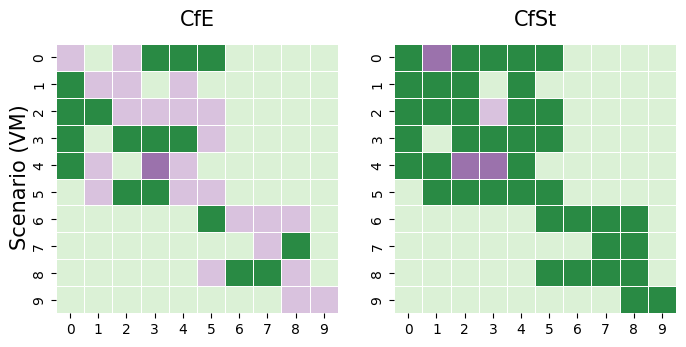

In [5]:
### Under Model (VM) ###

d = 10

mu = np.array([1.0, 1.3, 1.2, 0.8, 0.5, 0.3, 1.1, 1.0, 0.3, 1.5])

alpha = np.array( [ [0.5, 0.0, 0.2, -0.8, 0.5, 0.7, 0.0, 0.0, 0.0, 0.0],
                    [1.0, -0.5, -0.2, 0.0, 0.2, 0.0, 0.0, 0.0, 0.0, 0.0],
                    [0.2, -0.9, 0.7, 0.1, -0.1, 0.3, 0.0, 0.0, 0.0, 0.0],
                    [-0.4, 0.0, 1.2, -0.8, 0.2, 0.2, 0.0, 0.0, 0.0, 0.0],
                    [1.2, 0.3, 0.0, 0.0, 0.7, 0.0, 0.0, 0.0, 0.0, 0.0],
                    [0.0, -0.1, 1.0, -0.8, 0.1, 0.2, 0.0, 0.0, 0.0, 0.0],
                    [0.0, 0.0, 0.0, 0.0, 0.0, 0.5, -0.1, -0.2, -0.1, 0.0],
                    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.5, 0.0],
                    [0.0, 0.0, 0.0, 0.0, 0.0, 0.3, 0.3, 0.5, -0.1, 0.0],
                    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.4, 0.6] ])

beta = np.array([6.0, 3.0, 2.2, 3.6, 6.0, 1.4, 2.4, 2.0, 1.6, 2.4])

alpha_tilde = np.zeros((d,d))

####### Simulate data #######

nb_realisations = 25
size = 5000

hawkes_sim = ExponentialHawkesGVM(model='gvm', mu=mu, alpha=alpha, beta=beta, alpha_tilde=alpha_tilde)
times = hawkes_sim.simulate(size=size, nb_realisations=nb_realisations)

####### Estimate #######

hawkes = ExponentialHawkesGVM()
hawkes.fit(times)

hawkes.test_absence_interactions(asymptotic=False)
interaction_matrix_cfe = copy.deepcopy(hawkes.alpha_zero_coefficients)

hawkes.test_absence_interactions(asymptotic=True)
interaction_matrix_cfst = copy.deepcopy(hawkes.alpha_zero_coefficients)

fig, axes = plt.subplots(1,2,figsize=(8, 3.5))

colors = ["#ff8a8e", "white", "#00ff2c"]
custom_cmap_real = LinearSegmentedColormap.from_list("custom_cmap", colors)
custom_cmap = ListedColormap(["#dbf1d6","#9b72ac", "#d9c2de", "#298a44"]) 

# Cfe

categorical_matrix = np.ones((d, d))
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_matrix_cfe, 0, categorical_matrix)  # Correct zero
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_matrix_cfe, 1, categorical_matrix)  # Undetected zero
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_matrix_cfe, 2, categorical_matrix)  # False zero detected
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_matrix_cfe, 3, categorical_matrix)  # Correct non-zero

sns.heatmap(
    categorical_matrix,
    ax=axes[0],
    cmap=custom_cmap,
    annot=False,
    cbar=False,  
    vmin=0,
    vmax=4,
    linewidths=0.5,
    linecolor='white'
)

axes[0].tick_params(axis='x')
axes[0].tick_params(axis='y')

# Cfst

categorical_matrix = np.ones((d, d))
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_matrix_cfst, 0, categorical_matrix)  # Correct zero
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_matrix_cfst, 1, categorical_matrix)  # Undetected zero
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_matrix_cfst, 2, categorical_matrix)  # False zero detected
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_matrix_cfst, 3, categorical_matrix)  # Correct non-zero

sns.heatmap(
    categorical_matrix,
    ax=axes[1],
    cmap=custom_cmap,
    annot=False,
    cbar=False,  
    vmin=0,
    vmax=4,
    linewidths=0.5,
    linecolor='white'
)

axes[1].tick_params(axis='x')
axes[1].tick_params(axis='y')



titlesize = 15
pad = 13
axes[0].set_title(r"CfE", fontsize=titlesize, pad=pad)
axes[1].set_title(r"CfSt", fontsize=titlesize, pad=pad)
fig.text(0.08, 0.5,'Scenario (VM)', va='center', ha='center', rotation='vertical', fontsize=15)

plt.show()


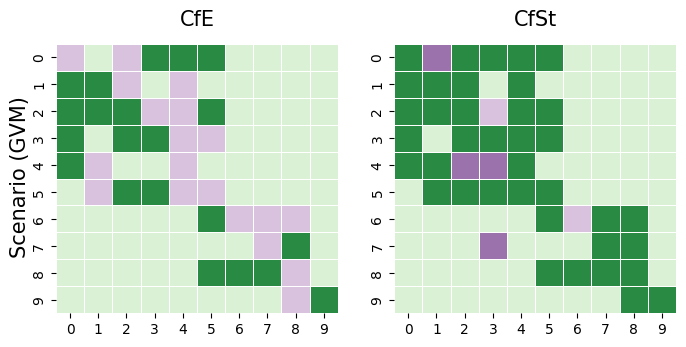

In [6]:
### Under Model (GVM) ### 

d = 10

mu = np.array([1.0, 1.3, 1.2, 0.8, 0.5, 0.3, 1.1, 1.0, 0.3, 1.5])

alpha = np.array( [ [0.5, 0.0, 0.2, -0.8, 0.5, 0.7, 0.0, 0.0, 0.0, 0.0],
                    [1.0, -0.5, -0.2, 0.0, 0.2, 0.0, 0.0, 0.0, 0.0, 0.0],
                    [0.2, -0.9, 0.7, 0.1, -0.1, 0.3, 0.0, 0.0, 0.0, 0.0],
                    [-0.4, 0.0, 1.2, -0.8, 0.2, 0.2, 0.0, 0.0, 0.0, 0.0],
                    [1.2, 0.3, 0.0, 0.0, 0.7, 0.0, 0.0, 0.0, 0.0, 0.0],
                    [0.0, -0.1, 1.0, -0.8, 0.1, 0.2, 0.0, 0.0, 0.0, 0.0],
                    [0.0, 0.0, 0.0, 0.0, 0.0, 0.5, -0.1, -0.2, -0.1, 0.0],
                    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.5, 0.0],
                    [0.0, 0.0, 0.0, 0.0, 0.0, 0.3, 0.3, 0.5, -0.1, 0.0],
                    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.4, 0.6] ])

beta = np.array([6.0, 3.0, 2.2, 3.6, 6.0, 1.4, 2.4, 2.0, 1.6, 2.4])

alpha_tilde = copy.deepcopy(alpha)
alpha_tilde[1,:] = np.zeros(d)
alpha_tilde[3,:] = np.zeros(d)
alpha_tilde[8,:] = np.zeros(d)

####### Simulate data #######

nb_realisations = 25
size = 5000

hawkes_sim = ExponentialHawkesGVM(model='gvm', mu=mu, alpha=alpha, beta=beta, alpha_tilde=alpha_tilde)
times = hawkes_sim.simulate(size=size, nb_realisations=nb_realisations)

####### Estimate #######

hawkes = ExponentialHawkesGVM()
hawkes.fit(times)

hawkes.test_absence_interactions(asymptotic=False)
interaction_matrix_cfe = copy.deepcopy(hawkes.alpha_zero_coefficients)

hawkes.test_absence_interactions(asymptotic=True)
interaction_matrix_cfst = copy.deepcopy(hawkes.alpha_zero_coefficients)

fig, axes = plt.subplots(1,2,figsize=(8, 3.5))

colors = ["#ff8a8e", "white", "#00ff2c"]
custom_cmap_real = LinearSegmentedColormap.from_list("custom_cmap", colors)
custom_cmap = ListedColormap(["#dbf1d6","#9b72ac", "#d9c2de", "#298a44"]) 

# Cfe

categorical_matrix = np.ones((d, d))
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_matrix_cfe, 0, categorical_matrix)  # Correct zero
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_matrix_cfe, 1, categorical_matrix)  # Undetected zero
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_matrix_cfe, 2, categorical_matrix)  # False zero detected
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_matrix_cfe, 3, categorical_matrix)  # Correct non-zero

sns.heatmap(
    categorical_matrix,
    ax=axes[0],
    cmap=custom_cmap,
    annot=False,
    cbar=False,  
    vmin=0,
    vmax=4,
    linewidths=0.5,
    linecolor='white'
)

axes[0].tick_params(axis='x')
axes[0].tick_params(axis='y')

# Cfst

categorical_matrix = np.ones((d, d))
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_matrix_cfst, 0, categorical_matrix)  # Correct zero
categorical_matrix = np.where(np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_matrix_cfst, 1, categorical_matrix)  # Undetected zero
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & interaction_matrix_cfst, 2, categorical_matrix)  # False zero detected
categorical_matrix = np.where(~np.logical_and(alpha_tilde == 0, alpha == 0) & ~interaction_matrix_cfst, 3, categorical_matrix)  # Correct non-zero

sns.heatmap(
    categorical_matrix,
    ax=axes[1],
    cmap=custom_cmap,
    annot=False,
    cbar=False,  
    vmin=0,
    vmax=4,
    linewidths=0.5,
    linecolor='white'
)

axes[1].tick_params(axis='x')
axes[1].tick_params(axis='y')



titlesize = 15
pad = 13
axes[0].set_title(r"CfE", fontsize=titlesize, pad=pad)
axes[1].set_title(r"CfSt", fontsize=titlesize, pad=pad)
fig.text(0.08, 0.5,'Scenario (GVM)', va='center', ha='center', rotation='vertical', fontsize=15)

plt.show()


# Asymptotic normality

In [3]:
####### Under HP #######

d = 2
alpha = np.array([[0.6, 0.0],[-0.6,1.2]])
beta = np.array([3.5,2.0])
mu = np.array([0.7,1.0])
alpha_tilde = alpha

####### Simulate data #######

nb_realisations = 1000
size = 5000

hawkes = ExponentialHawkesGVM(model='gvm', mu=mu, alpha=alpha, beta=beta, alpha_tilde=alpha)
times = hawkes.simulate(size=size, nb_realisations=nb_realisations)

hawkes.fit(times)


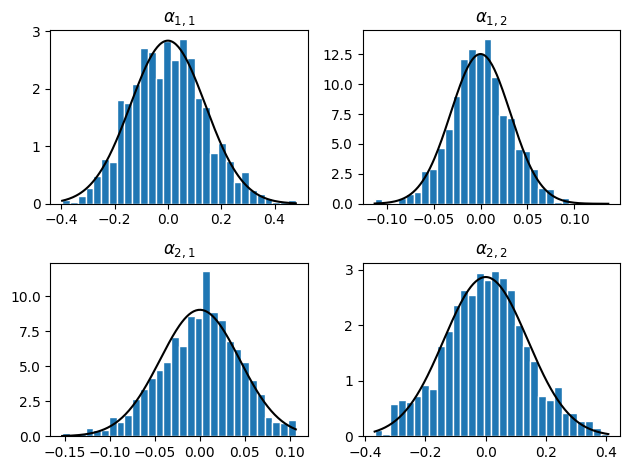

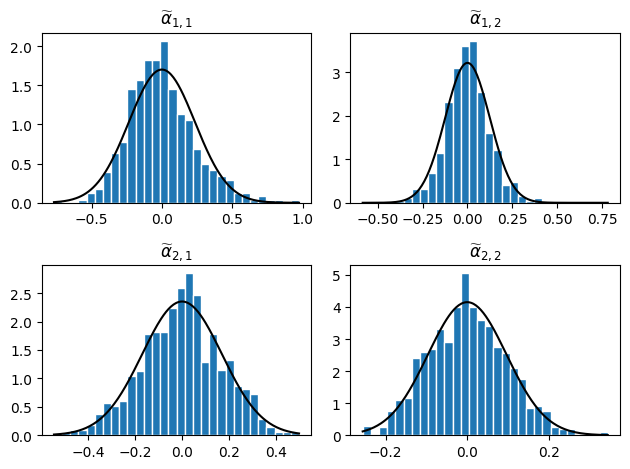

In [5]:
fig,ax = plt.subplots(2,2)
p_values = np.zeros((d,d))
for i in range(2):
    for j in range(2):
        estimations = [e[1][i,j] for e in hawkes.multiple_estimations]
        mean = np.mean(estimations)
        std = np.std(estimations)
        data = (estimations-mean)/std
        p_values[i,j] = kstest(data,'norm').pvalue
            
        ax[i,j].hist(estimations-mean, edgecolor='white', bins=30, density=True)
        
        x = np.linspace(min(estimations - mean), max(estimations - mean), 200)
        gaussian = (1 / (std * np.sqrt(2*np.pi))) * np.exp(-0.5 * (x / std)**2)
        ax[i,j].plot(x, gaussian, color='black')
        
        ax[i,j].set_title(fr'$\alpha_{{{i+1},{j+1}}}$')

plt.tight_layout()
plt.show()

fig,ax = plt.subplots(2,2)
p_values_tilde = np.zeros((d,d))
for i in range(2):
    for j in range(2):
        estimations = [e[3][i,j] for e in hawkes.multiple_estimations]
        mean = np.mean(estimations)
        std = np.std(estimations)
        data = (estimations-mean)/std
        p_values_tilde[i,j] = kstest(data,'norm').pvalue
            
        ax[i,j].hist(estimations-mean, edgecolor='white', bins=30, density=True)

        x = np.linspace(min(estimations - mean), max(estimations - mean), 200)
        gaussian = (1 / (std * np.sqrt(2*np.pi))) * np.exp(-0.5 * (x / std)**2)
        ax[i,j].plot(x, gaussian,color='black')
        
        ax[i,j].set_title(fr'$\widetilde\alpha_{{{i+1},{j+1}}}$')

plt.tight_layout()
plt.show()



# Comparison final estimator computation

In [35]:
with open("results_sim/times_dim2_hp.txt", "r") as file:
    file_content = file.read()
exec(file_content)


with open("results_sim/scenario_hp_dim2_under_gvm.txt", "r") as file:
    file_content = file.read()
exec(file_content)

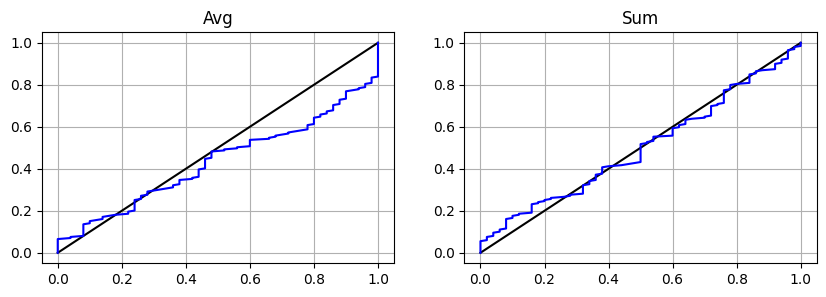

Average p-value:
 With average estimation: 0.43311910534984593 
 With estimation with sum of log-likelihoods: 0.5005002947218723 


Log-likelihood:
 With average estimation: -53308.058120398986 
 With estimation with sum of log-likelihoods: -53303.11912082217


In [39]:
hawkes = ExponentialHawkesGVM()

d=2
hawkes.times = times
hawkes.d = d
hawkes.nb_realisations = 25
hawkes.multiple_estimations = hp_gvm_estimations_step5
hawkes.calculate_average_estimation()
hawkes.estimation = hp_gvm_final_estimation

nb_iterations = 50
pvalues_av = hawkes.pvalues(nb_iterations=nb_iterations, av_estimation=True)
pvalues_nonav = hp_gvm_pvalues

hawkes.alpha_zero_coefficients = hp_gvm_interaction_matrix
hawkes.alpha_tilde_zero_coefficients = hp_gvm_matrix_vm
hawkes.equal_coefficients = hp_gvm_matrix_hp
hawkes.nb_params = 2*d + 2*d*d - (hawkes.alpha_zero_coefficients).sum() - (hawkes.alpha_tilde_zero_coefficients).sum() - (np.logical_and(hawkes.equal_coefficients, ~hawkes.alpha_tilde_zero_coefficients)).sum()

fig,ax=plt.subplots(1,2,figsize=(10,3))
nb = 200
y = np.linspace(0, 1, nb)

values_av = np.array([np.sum(pvalues_av <= yk) / nb_iterations for yk in y])
values_nonav = np.array([np.sum(pvalues_nonav <= yk) / nb_iterations for yk in y])

ax[0].plot(y, y, color='black')
ax[0].plot(values_av, y,color='blue')
ax[0].set_title('Avg')
ax[0].grid()

ax[1].plot(y, y, color='black')
ax[1].plot(values_nonav, y,color='blue')
ax[1].set_title('Sum')
ax[1].grid()

plt.show()

print('Average p-value:\n',
      'With average estimation:', np.mean(pvalues_av),'\n',
      'With estimation with sum of log-likelihoods:', np.mean(pvalues_nonav),'\n\n')

print('Log-likelihood:\n',
      'With average estimation:',-hawkes.negloglikelihood_with_grad_jit(hawkes.flatten_parameters(hawkes.average_estimation))[0],'\n',
      'With estimation with sum of log-likelihoods:', -hawkes.negloglikelihood_with_grad_jit(hawkes.flatten_parameters(hawkes.estimation))[0])

